#  Black-Scholes Option Pricing

## 1. Research Objective

This notebook moves away from the US Equities market and will investigate the Black-Scholes model for pricing European call and put options. The aim is to implement the pricing formulas and explain the underlying mathematics and verify the results using put-call parity.

## 2. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

## 3. Option Pricing Foundations


A European call option gives its holder the right, but not the obligation, to purchase an underlying asset at a fixed strike price on the expiration date.

A European put option gives its holder the right, but not the obligation, to sell the underlying asset at the strike price on the expiration date.

The payoff of a European call option at maturity is $\max(S_T-K,0)$.

The payoff of a European put option at maturity is $\max(K-S_T,0)$.

Here, $S_T$ represents the underlying asset price at maturity and $K$ represents the option's strike price.

## 4. Black_Scholes Assumptions

The standard Black–Scholes model relies on several assumptions:

- The option can only be exercised at maturity.
- The underlying asset pays no dividends.
- The risk-free interest rate is constant.
- Volatility is constant.
- There are no transaction costs or taxes.
- The underlying asset price follows geometric Brownian motion.
- Trading can occur continuously.
- There are no arbitrage opportunities.

## 5. Black-Scholes Formula

For a European Call:

$$ C = S_0 N(d_1) - K e^{-rT} N(d_2) $$

For a European Put:

$$ P = K e^{-rT} N(-d_2) - S_0 N(-d_1) $$

where: 

$$ d_1 = \frac{\ln(S_0 / K) + (r + \frac{1}{2} \sigma^2)T}{\sigma \sqrt{T}} $$

and:

$$  d_2 = d_1 - \sigma \sqrt{T} $$



Here, $S_0$ is the current asset price, $K$ is the strike price, $r$ is the continuously compounded risk-free interest rate, $T$ is the time to maturity in years, $\sigma$ is annualised volatility, and $N(\cdot)$ is the standard normal cumulative distribution function.

The quantities $d_1$ and $d_2$ are intermediate variables that arise in the derivation of the Black–Scholes model. They combine the effects of the current asset price, strike price, volatility, interest rate and time to maturity into two standardised values.

The quantity $d_1$ reflects how many standard deviations the expected future asset price is above or below the strike price under the risk-neutral measure, while $d_2$ adjusts this value by one standard deviation of the asset's returns over the option's lifetime.

## 6. Implementing the Formula

In [5]:
def calculate_d1(S0, K, r, T, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return d1


def calculate_d2(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return d2

def black_scholes_call(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = calculate_d2(S0, K, r, T, sigma)
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def black_scholes_put(S0, K, r, T, sigma):
    d1 = calculate_d1(S0, K, r, T, sigma)
    d2 = calculate_d2(S0, K, r, T, sigma)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return put_price

## 7. Testing the Functions

In [6]:
S0 = 100
K = 100
r = 0.05
T = 1
sigma = 0.20

call_price = black_scholes_call(S0, K, r, T, sigma)
put_price = black_scholes_put(S0, K, r, T, sigma)

print("European Call Price:", call_price)
print("European Put Price:", put_price)

European Call Price: 10.450583572185565
European Put Price: 5.573526022256971


In [7]:
d1 = calculate_d1(S0, K, r, T, sigma)
d2 = calculate_d2(S0, K, r, T, sigma)

print(f"d1 = {d1:.4f}")
print(f"d2 = {d2:.4f}")

d1 = 0.3500
d2 = 0.1500


## 8. Put-Call Parity

Put–call parity is the relationship between the prices of European call and put options with the same strike price and expiration date, given by:

$C-P=S_0-Ke^{-rT}$

where $C$ and $P$ denote the prices of the European call and put options respectively.

Verifying this relationship provides an important consistency check for the Black–Scholes implementation. If the equality holds (up to numerical precision), the pricing functions are behaving correctly.

In [8]:
left_hand_side = call_price - put_price
right_hand_side = S0 - K * np.exp(-r * T)

print(f"Call - Put = {left_hand_side:.6f}")
print(f"S₀ - Ke^(-rT) = {right_hand_side:.6f}")

Call - Put = 4.877058
S₀ - Ke^(-rT) = 4.877058


This is perfect, and shows are code can now be used for actual use.

## 9. Option Payoff Diagrams

The Black–Scholes model determines the fair value of an option before expiration, which should differ from the option's price at maturity.

The payoff depends only on the asset price at expiration and is independent of the probability distribution of future prices. Visualising option payoffs provides intuition for how options generate profits and losses under different market outcomes.

### 9.1 Plotting the European Call Option Payoff

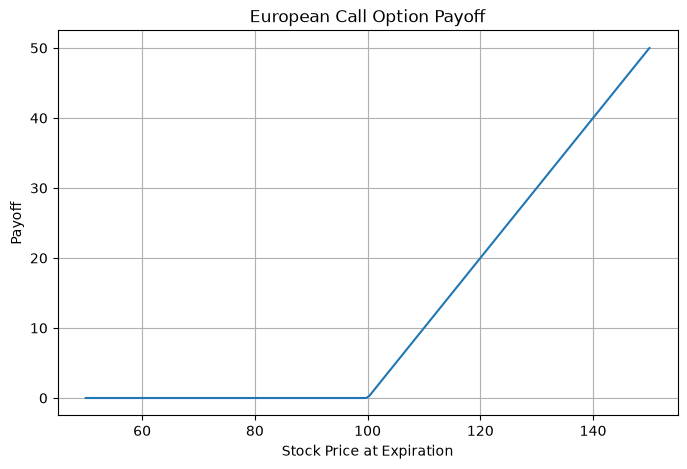

In [9]:
stock_prices = np.linspace(50, 150, 200)

call_payoff = np.maximum(stock_prices - K, 0)

plt.figure(figsize=(8,5))

plt.plot(stock_prices, call_payoff)

plt.title("European Call Option Payoff")
plt.xlabel("Stock Price at Expiration")
plt.ylabel("Payoff")

plt.grid(True)

plt.show()

### 9.2 Plot of the European Put Option Payoff

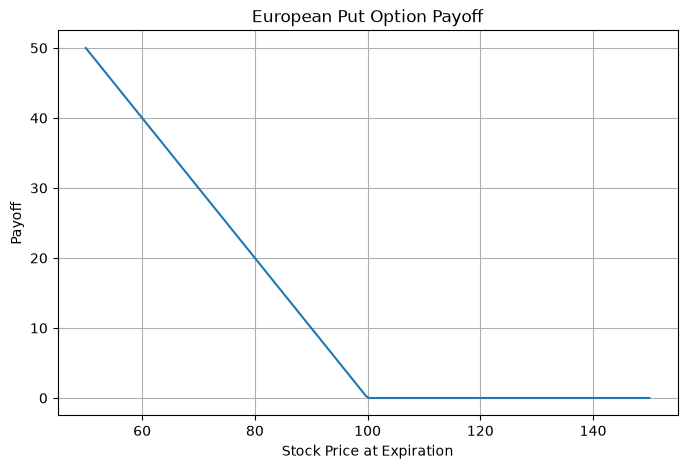

In [10]:
put_payoff = np.maximum(K - stock_prices, 0)

plt.figure(figsize=(8,5))

plt.plot(stock_prices, put_payoff)

plt.title("European Put Option Payoff")
plt.xlabel("Stock Price at Expiration")
plt.ylabel("Payoff")

plt.grid(True)

plt.show()

### 9.3 Combined Figure

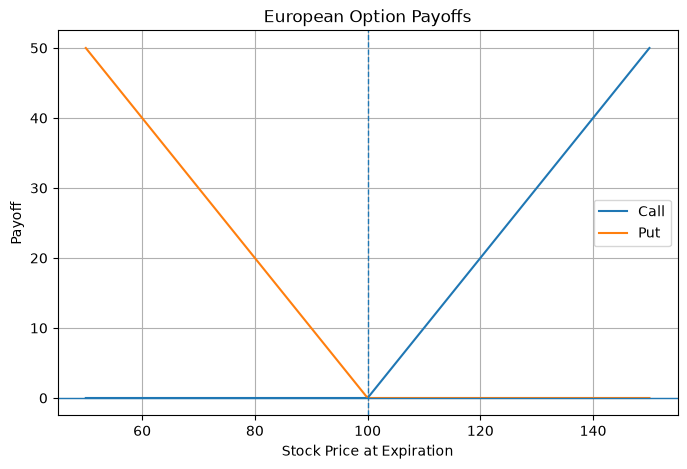

In [11]:
plt.figure(figsize=(8,5))

plt.plot(stock_prices, call_payoff, label="Call")
plt.plot(stock_prices, put_payoff, label="Put")

plt.axhline(0, linewidth=1)
plt.axvline(K, linestyle="--", linewidth=1)

plt.xlabel("Stock Price at Expiration")
plt.ylabel("Payoff")
plt.title("European Option Payoffs")

plt.legend()

plt.grid(True)

plt.show()

These payoff diagrams show the asymmetry between European options.

## 10. Pricing Real European Option

We now look to apply the Black-Scholes theory to a listed Mini-SPX index option, which trade under the ticker XSP. The aim in this section is to select a real XSP call option, calculate its theoretical Black-Scholes value and compare the result with the observed market price.

### 10.1 Import Additional Libraries

In [12]:
import pandas as pd
import yfinance as yf

from datetime import datetime

### 10.2 Download the XSP Option

In [29]:
xsp = yf.Ticker("^XSP")

today = pd.Timestamp.today().normalize()

expiration_table = pd.DataFrame(
    {
        "expiration": pd.to_datetime(expiration_dates)
    }
)

expiration_table["days_to_expiration"] = (
    expiration_table["expiration"] - today
).dt.days

valid_expirations = expiration_table[
    (expiration_table["days_to_expiration"] >= 30)
    & (expiration_table["days_to_expiration"] <= 90)
]

valid_expirations

if valid_expirations.empty:
    raise ValueError("No expiration dates were found between 30 and 90 days.")

selected_row = valid_expirations.iloc[
    (valid_expirations["days_to_expiration"] - 60).abs().argsort()[:1]
]

selected_expiration = selected_row["expiration"].iloc[0].strftime("%Y-%m-%d")

print("Selected expiration:", selected_expiration)
print(
    "Days to expiration:",
    selected_row["days_to_expiration"].iloc[0]
)

Selected expiration: 2026-09-30
Days to expiration: 62


### 10.3 Retrieve the Option Chain

In [30]:
option_chain = xsp.option_chain(selected_expiration)

calls = option_chain.calls
puts = option_chain.puts

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,XSP260930C00375000,2026-05-08 16:44:03+00:00,375.0,367.92,366.59,370.79,0.0,0.0,NaN,0,0.823488,True,REGULAR,USD
1,XSP260930C00380000,2026-05-22 19:37:44+00:00,380.0,371.25,370.81,372.44,0.0,0.0,1.0,0,1.161503,True,REGULAR,USD
2,XSP260930C00500000,2026-05-07 19:04:27+00:00,500.0,240.43,244.32,248.69,0.0,0.0,3.0,8,0.623600,True,REGULAR,USD
3,XSP260930C00510000,2026-05-07 19:04:27+00:00,510.0,230.77,234.60,239.16,0.0,0.0,NaN,3,0.609135,True,REGULAR,USD
4,XSP260930C00520000,2026-06-12 15:53:39+00:00,520.0,230.22,239.27,242.93,0.0,0.0,NaN,1,0.867799,True,REGULAR,USD


### 10.4 Obtain the Current Index Level

In [31]:
xsp_history = xsp.history(period="5d")

S0_market = xsp_history["Close"].iloc[-1]

print(f"Current XSP level: {S0_market:.2f}")

Current XSP level: 742.15


### 10.5 Select a Near-The-Money Call

In [32]:
calls = calls.copy()

calls["distance_from_spot"] = np.abs(calls["strike"] - S0_market)

selected_call = calls.sort_values("distance_from_spot").iloc[0]

selected_call

contractSymbol               XSP260930C00742000
lastTradeDate         2026-07-30 01:51:24+00:00
strike                                    742.0
lastPrice                                 17.67
bid                                       20.27
ask                                        20.6
change                                      0.4
percentChange                          2.316153
volume                                     10.0
openInterest                                 30
impliedVolatility                      0.166863
inTheMoney                                 True
contractSize                            REGULAR
currency                                    USD
distance_from_spot                     0.150024
Name: 83, dtype: object

And now extract the key values from this information.

In [33]:
K_market = selected_call["strike"]
market_bid = selected_call["bid"]
market_ask = selected_call["ask"]
market_last = selected_call["lastPrice"]
implied_volatility = selected_call["impliedVolatility"]

print(f"Underlying level: {S0_market:.2f}")
print(f"Strike price: {K_market:.2f}")
print(f"Bid price: {market_bid:.2f}")
print(f"Ask price: {market_ask:.2f}")
print(f"Last traded price: {market_last:.2f}")
print(f"Implied volatility: {implied_volatility:.4f}")

Underlying level: 742.15
Strike price: 742.00
Bid price: 20.27
Ask price: 20.60
Last traded price: 17.67
Implied volatility: 0.1669


### 10.6 Calculate the Market Midpoint

In [34]:
if market_bid > 0 and market_ask > 0:
    market_midpoint = (market_bid + market_ask) / 2
else:
    market_midpoint = market_last

print(f"Market comparison price: {market_midpoint:.2f}")

Market comparison price: 20.44


### 10.7 Calculate Time to Maturity

Now we have the data, we can begin to use the Black-Scholes model by first of all calculating the time to maturity:

$$T=\dfrac{\text{Number of calendar days until expiration}}{365}$$

In [35]:
valuation_date = pd.Timestamp.today().normalize()
expiration_date = pd.Timestamp(selected_expiration)

days_to_expiration = (expiration_date - valuation_date).days
T_market = days_to_expiration / 365

print(f"Days to expiration: {days_to_expiration}")
print(f"Time to maturity: {T_market:.6f} years")

Days to expiration: 62
Time to maturity: 0.169863 years


### 10.8 Choose a Risk-Free Rate

In [47]:
r_market = 0.03

### 10.9 Calculate the Black-Scholes Price

In [48]:
black_scholes_market_price = black_scholes_call(
    S0_market,
    K_market,
    r_market,
    T_market,
    implied_volatility
)

print(f"Black–Scholes call price: {black_scholes_market_price:.4f}")
print(f"Observed market midpoint: {market_midpoint:.4f}")

Black–Scholes call price: 22.3248
Observed market midpoint: 20.4350


### 10.10 Calculate the Pricing Difference

In [49]:
pricing_error = black_scholes_market_price - market_midpoint
absolute_error = np.abs(pricing_error)

if market_midpoint > 0:
    percentage_error = absolute_error / market_midpoint * 100
else:
    percentage_error = np.nan

print(f"Pricing error: {pricing_error:.4f}")
print(f"Absolute pricing error: {absolute_error:.4f}")
print(f"Percentage error: {percentage_error:.2f}%")

Pricing error: 1.8898
Absolute pricing error: 1.8898
Percentage error: 9.25%


### 10.11 Results

In [50]:
comparison = pd.DataFrame(
    {
        "Underlying": [S0_market],
        "Strike": [K_market],
        "Time to Maturity": [T_market],
        "Risk-Free Rate": [r_market],
        "Implied Volatility": [implied_volatility],
        "Market Midpoint": [market_midpoint],
        "Black-Scholes Price": [black_scholes_market_price],
        "Absolute Error": [absolute_error],
        "Percentage Error": [percentage_error]
    }
)

comparison.round(4)

,Underlying,Strike,Time to Maturity,Risk-Free Rate,Implied Volatility,Market Midpoint,Black-Scholes Price,Absolute Error,Percentage Error
0,742.15,742.0,0.1699,0.03,0.1669,20.435,22.3248,1.8898,9.2477


As we can see the error in Black-Scholes is $\approx 9.25%$.

Although the theoretical value exceeds the observed market midpoint, the prices remain reasonably close given the simplifying assumptions of the Black–Scholes model. Differences of can arise from bid–ask spreads, the assumed risk-free interest rate, rounding, and the precise timing of the market data used.